In [207]:
# Packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
from matplotlib import pyplot
import numpy as np
import pandas as pd
import seaborn
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import sys
# Open flood_tool package
sys.path.append('../..')
# Open functions from geo.py
sys.path.append('..')
from geo import get_gps_lat_long_from_easting_northing
from tool import Tool

## Opening Dataset

In [208]:
# Open dataset
DF_orig = pd.read_csv("../resources/postcodes_labelled.csv")
DF_orig

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,riskLabel,medianPrice,historicallyFlooded
0,BA10 0AD,368289,134886,Unsurveyed/Urban,70,Combe Brook,770.0,South Somerset,3,520900.0,0
1,BA10 0AG,368240,134813,Unsurveyed/Urban,60,Combe Brook,840.0,South Somerset,3,513200.0,0
2,BA10 0AZ,367936,134742,Unsurveyed/Urban,60,Combe Brook,970.0,South Somerset,3,850600.0,0
3,BA10 0BB,367980,134623,Unsurveyed/Urban,60,Combe Brook,1070.0,South Somerset,6,413100.0,1
4,BA10 0BH,367942,134697,Unsurveyed/Urban,60,Combe Brook,1010.0,South Somerset,3,525500.0,0
...,...,...,...,...,...,...,...,...,...,...,...
79995,W6 0SB,521913,178731,Unsurveyed/Urban,10,River Thames,1710.0,Hounslow,4,465400.0,0
79996,W6 0XX,521848,178945,Unsurveyed/Urban,10,River Thames,1930.0,Hounslow,4,1793100.0,0
79997,W6 0XY,521796,179018,Unsurveyed/Urban,10,River Thames,2020.0,Hounslow,4,2491200.0,0
79998,W6 0YB,521889,178957,Unsurveyed/Urban,10,River Thames,1920.0,Hounslow,4,2496800.0,0


In [209]:
# Calculate percentage of missing values in each column
missing = DF_orig.isnull().sum() / len(DF_orig)
missing

postcode                 0.000000
easting                  0.000000
northing                 0.000000
soilType                 0.000000
elevation                0.000000
nearestWatercourse       0.392300
distanceToWatercourse    0.000000
localAuthority           0.000000
riskLabel                0.000000
medianPrice              0.000087
historicallyFlooded      0.000000
dtype: float64

In [210]:
# Create list of columns that will need imputing
columns_impute = list(missing[missing > 0.0].index)
columns_impute

['nearestWatercourse', 'medianPrice']

## Converting Coordinates

In [211]:
# Convert coordinates from easting and northing to longitude and longitude
def Convert_Coords(DF_orig):
    DF = DF_orig.copy()
# Get longitude latitude coordinates
    lats, lons = get_gps_lat_long_from_easting_northing(DF_orig['easting'], DF_orig['northing'])
# Add latitude longitude coordinates into dataframe
    DF['longitude'] = lons
    DF['latitude'] = lats
    return (DF)
# Apply function
DF_V1 = Convert_Coords(DF_orig)
DF_V1

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,riskLabel,medianPrice,historicallyFlooded,longitude,latitude
0,BA10 0AD,368289,134886,Unsurveyed/Urban,70,Combe Brook,770.0,South Somerset,3,520900.0,0,-2.454381,51.112382
1,BA10 0AG,368240,134813,Unsurveyed/Urban,60,Combe Brook,840.0,South Somerset,3,513200.0,0,-2.455075,51.111723
2,BA10 0AZ,367936,134742,Unsurveyed/Urban,60,Combe Brook,970.0,South Somerset,3,850600.0,0,-2.459411,51.111068
3,BA10 0BB,367980,134623,Unsurveyed/Urban,60,Combe Brook,1070.0,South Somerset,6,413100.0,1,-2.458772,51.110000
4,BA10 0BH,367942,134697,Unsurveyed/Urban,60,Combe Brook,1010.0,South Somerset,3,525500.0,0,-2.459321,51.110663
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,W6 0SB,521913,178731,Unsurveyed/Urban,10,River Thames,1710.0,Hounslow,4,465400.0,0,-0.245249,51.494386
79996,W6 0XX,521848,178945,Unsurveyed/Urban,10,River Thames,1930.0,Hounslow,4,1793100.0,0,-0.246111,51.496324
79997,W6 0XY,521796,179018,Unsurveyed/Urban,10,River Thames,2020.0,Hounslow,4,2491200.0,0,-0.246835,51.496991
79998,W6 0YB,521889,178957,Unsurveyed/Urban,10,River Thames,1920.0,Hounslow,4,2496800.0,0,-0.245517,51.496423


In [212]:
# Statistics
DF_V1.describe()

,easting,northing,elevation,distanceToWatercourse,riskLabel,medianPrice,historicallyFlooded,longitude,latitude
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,7.999300e+04,80000.000000,80000.000000,80000.000000
mean,448242.209975,133712.121588,54.940250,1358.228625,1.701588,4.781950e+05,0.022562,-1.306479,51.089755
std,112164.286320,37444.052751,45.264274,1378.841484,1.211427,6.774985e+05,0.148505,1.595001,0.340245
min,88907.000000,10216.000000,-10.000000,0.000000,1.000000,1.000000e+02,0.000000,-6.338694,49.912333
25%,382871.000000,105901.750000,20.000000,610.000000,1.000000,2.864000e+05,0.000000,-2.246097,50.843468
50%,473167.000000,139926.000000,40.000000,1040.000000,1.000000,3.819000e+05,0.000000,-0.954340,51.135683
75%,528080.000000,166771.750000,80.000000,1700.000000,2.000000,5.405000e+05,0.000000,-0.160580,51.389234
max,639960.000000,210573.000000,430.000000,47600.000000,7.000000,7.692600e+07,1.000000,1.445939,51.790659


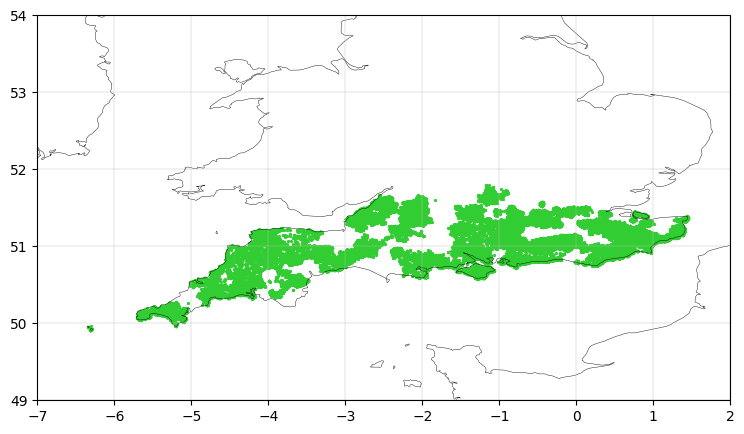

In [213]:
# Plot map of locations
Fig = pyplot.figure(figsize=(9,5))
# Add coastlines and borders
Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
Axis.coastlines(linewidth=0.3)
Axis.add_feature(cfeature.BORDERS, linewidth=0.2)
# Plot stations
pyplot.scatter(DF_V1['longitude'], DF_V1['latitude'], c='limegreen', s=1.8)
# Formatting
x_Axis = np.arange(-7, 3, 1)
y_Axis = np.arange(49, 55, 1)
Axis.set_xlim(-7,2)
Axis.set_ylim(49,54)
Axis.set_xticks(x_Axis)
Axis.set_yticks(y_Axis)
Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.show()

## Getting Postcode District and Postcode Sector

In [214]:
# Function to get postcode district from postcode
def Postcode_District(Postcode):
# Normal scenario
    if " " in Postcode:
        Split = Postcode.split()
        District = Split[0].upper()
# Bad formatting
    else:
        Outward = Postcode[:-3].strip("_").strip("-").strip("+")
        District = Outward.upper()
    return (District)

In [215]:
# Function to get postcode sector from postcode
def Postcode_Sector(Postcode):
# Normal scenario
    if " " in Postcode:
        Split = Postcode.split()
        Outward = Split[0]
        Inward = Split[1]
        Sector = str(Outward + " " + Inward[0]).upper()
# Bad formatting
    else:
        Inward = Postcode[-3:]
        Outward = Postcode[:-3].strip("_").strip("-").strip("+")
        Sector = str(Outward + " " + Inward[0]).upper()
    return (Sector)

In [216]:
# Add postcode district and postcode sector into dataframe
def Add_Postcode_District_Sector(DF_orig):
    DF = DF_orig.copy()
    Districts = []
    Sectors = []
# Find postcode district and postcode sector for each postcode in dataframe
    for i in range(len(DF)):
        Districts.append(Postcode_District(DF['postcode'][i]))
        Sectors.append(Postcode_Sector(DF['postcode'][i]))
# Add new column to dataframe
    DF['postcodeDistrict'] = Districts
    DF['postcodeSector'] = Sectors
    return (DF)
# Apply function
DF_V2 = Add_Postcode_District_Sector(DF_V1)
DF_V2

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,riskLabel,medianPrice,historicallyFlooded,longitude,latitude,postcodeDistrict,postcodeSector
0,BA10 0AD,368289,134886,Unsurveyed/Urban,70,Combe Brook,770.0,South Somerset,3,520900.0,0,-2.454381,51.112382,BA10,BA10 0
1,BA10 0AG,368240,134813,Unsurveyed/Urban,60,Combe Brook,840.0,South Somerset,3,513200.0,0,-2.455075,51.111723,BA10,BA10 0
2,BA10 0AZ,367936,134742,Unsurveyed/Urban,60,Combe Brook,970.0,South Somerset,3,850600.0,0,-2.459411,51.111068,BA10,BA10 0
3,BA10 0BB,367980,134623,Unsurveyed/Urban,60,Combe Brook,1070.0,South Somerset,6,413100.0,1,-2.458772,51.110000,BA10,BA10 0
4,BA10 0BH,367942,134697,Unsurveyed/Urban,60,Combe Brook,1010.0,South Somerset,3,525500.0,0,-2.459321,51.110663,BA10,BA10 0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,W6 0SB,521913,178731,Unsurveyed/Urban,10,River Thames,1710.0,Hounslow,4,465400.0,0,-0.245249,51.494386,W6,W6 0
79996,W6 0XX,521848,178945,Unsurveyed/Urban,10,River Thames,1930.0,Hounslow,4,1793100.0,0,-0.246111,51.496324,W6,W6 0
79997,W6 0XY,521796,179018,Unsurveyed/Urban,10,River Thames,2020.0,Hounslow,4,2491200.0,0,-0.246835,51.496991,W6,W6 0
79998,W6 0YB,521889,178957,Unsurveyed/Urban,10,River Thames,1920.0,Hounslow,4,2496800.0,0,-0.245517,51.496423,W6,W6 0


In [217]:
# Test functions on mangled dataset
DF_mangled = pd.read_csv("../resources/example_data/postcodes_mangled.csv")
DF_mangled

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,po9 5ea,472101,108419,Unsurveyed/Urban,40,NaN,1530.0,Havant
1,Ex15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon
2,PO144RJ,452325,106646,Unsurveyed/Urban,40,NaN,1270.0,Fareham
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth
4,PL2 2YZ,250353,53862,Unsurveyed/Urban,10,Pomphlett Lake,130.0,Plymouth
5,gu222ws,500739,158609,Unsurveyed/Urban,40,Basingstoke Canal,1020.0,Woking
6,SN8_1EA,418847,169121,Unsurveyed/Urban,130,River Kennet,260.0,Wiltshire
7,SE2-0XP,546019,177982,Unsurveyed/Urban,20,NaN,530.0,Greenwich
8,RG12+1NB,486242,169497,Unsurveyed/Urban,60,NaN,460.0,Bracknell Forest
9,SO1 8BJ,438705,115550,Unsurveyed/Urban,30,Tanner's Brook,810.0,Southampton


In [218]:
# Test functions on mangled dataset
Add_Postcode_District_Sector(DF_mangled)

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,postcodeDistrict,postcodeSector
0,po9 5ea,472101,108419,Unsurveyed/Urban,40,NaN,1530.0,Havant,PO9,PO9 5
1,Ex15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon,EX15,EX15 3
2,PO144RJ,452325,106646,Unsurveyed/Urban,40,NaN,1270.0,Fareham,PO14,PO14 4
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth,SE24,SE24 9
4,PL2 2YZ,250353,53862,Unsurveyed/Urban,10,Pomphlett Lake,130.0,Plymouth,PL2,PL2 2
5,gu222ws,500739,158609,Unsurveyed/Urban,40,Basingstoke Canal,1020.0,Woking,GU22,GU22 2
6,SN8_1EA,418847,169121,Unsurveyed/Urban,130,River Kennet,260.0,Wiltshire,SN8,SN8 1
7,SE2-0XP,546019,177982,Unsurveyed/Urban,20,NaN,530.0,Greenwich,SE2,SE2 0
8,RG12+1NB,486242,169497,Unsurveyed/Urban,60,NaN,460.0,Bracknell Forest,RG12,RG12 1
9,SO1 8BJ,438705,115550,Unsurveyed/Urban,30,Tanner's Brook,810.0,Southampton,SO1,SO1 8


## Imputing Missing Data Based on Postcode Sector and District

In [219]:
# Impute missing data using postcode sectors and districts
def Impute_Postcode_Method(DF_orig, columns_impute):
    DF = DF_orig.copy()
# Seperate columns that need imputing into numerical and categorical
    columns_impute_num = list(DF_orig[columns_impute].select_dtypes(include=[np.number]).columns)
    columns_impute_cat = list(DF_orig[columns_impute].select_dtypes(exclude=[np.number]).columns)
#
# Numerical columns
    if len(columns_impute_num) > 0:
# First try imputing with median of each postcode sector
        Sector_Medians = DF.groupby("postcodeSector")[columns_impute_num].transform("median")
        for col in columns_impute_num:
            DF[col] = DF[col].fillna(Sector_Medians[col])
# Continue imputing with median of each postcode district
        District_Medians = DF.groupby("postcodeDistrict")[columns_impute_num].transform("median")
        for col in columns_impute_num:
            DF[col] = DF[col].fillna(District_Medians[col])
# Impute with median of entire dataset if all else fails
        for col in columns_impute_num:
            Median = np.nanmedian(DF[col])
            DF[col] = DF[col].fillna(Median)
#
# Categorical columns
    if len(columns_impute_cat) > 0:
# First try imputing with mode of each postcode sector
        District_Modes = DF.groupby("postcodeDistrict")[columns_impute_cat].transform(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)
        for col in columns_impute_cat:
            DF[col] = DF[col].fillna(District_Modes[col])
# Continue imputing with mode of each postcode district
        Sector_Modes = DF.groupby("postcodeSector")[columns_impute_cat].transform(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)
        for col in columns_impute_cat:
            DF[col] = DF[col].fillna(Sector_Modes[col])
# Impute with mode of entire dataset if all else fails
        for col in columns_impute_cat:
            Mode = DF[col].mode().iat[0]
            DF[col] = DF[col].fillna(Mode)
    return (DF)

In [220]:
DF_V3 = Impute_Postcode_Method(DF_V2, columns_impute)

In [221]:
# Calculate percentage of missing values in each column
missing = DF_V3.isnull().sum() / len(DF_V3)
missing

postcode                 0.0
easting                  0.0
northing                 0.0
soilType                 0.0
elevation                0.0
nearestWatercourse       0.0
distanceToWatercourse    0.0
localAuthority           0.0
riskLabel                0.0
medianPrice              0.0
historicallyFlooded      0.0
longitude                0.0
latitude                 0.0
postcodeDistrict         0.0
postcodeSector           0.0
dtype: float64

In [222]:
# Test functions on missing data dataset
DF_missing = pd.read_csv("../resources/example_data/postcodes_missing_data.csv")
DF_missing

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,RG6 3AP,475996,170644,Gleysols,NaN,River Loddon,NaN,Wokingham
1,DA11 9BB,561117,175837,Gleysols,0.0,NaN,210.0,Gravesham
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,NaN,River Frome,590.0,"Bristol, City of"
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,NaN,NaN,NaN
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,NaN,NaN
...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,NaN,NaN,NaN,Eastbourne
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,NaN,1710.0,Epsom and Ewell
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,NaN,NaN,Brighton and Hove
998,BH22 8SG,408515,98030,NaN,20.0,NaN,950.0,Dorset


In [223]:
# Calculate percentage of missing values in each column
missing = DF_missing.isnull().sum() / len(DF_missing)
missing

postcode                 0.000
easting                  0.000
northing                 0.000
soilType                 0.321
elevation                0.327
nearestWatercourse       0.562
distanceToWatercourse    0.331
localAuthority           0.317
dtype: float64

In [224]:
# Create list of columns that will need imputing
DF_missing_columns_impute = list(missing[missing > 0.0].index)
DF_missing_columns_impute

['soilType',
 'elevation',
 'nearestWatercourse',
 'distanceToWatercourse',
 'localAuthority']

In [225]:
# Test functions on missing data dataset
DF_missing_V1 = Add_Postcode_District_Sector(DF_missing)
Impute_Postcode_Method(DF_missing_V1, DF_missing_columns_impute)

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,postcodeDistrict,postcodeSector
0,RG6 3AP,475996,170644,Gleysols,40.0,River Loddon,910.0,Wokingham,RG6,RG6 3
1,DA11 9BB,561117,175837,Gleysols,0.0,River Thames,210.0,Gravesham,DA11,DA11 9
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,50.0,River Frome,590.0,"Bristol, City of",BS5,BS5 6
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,River Thames,1170.0,Cornwall,RG2,RG2 0
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,1170.0,Cornwall,DA4,DA4 0
...,...,...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,10.0,River Thames,2000.0,Eastbourne,BN21,BN21 4
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,River Thames,1710.0,Epsom and Ewell,KT18,KT18 5
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,River Thames,1170.0,Brighton and Hove,BN50,BN50 9
998,BH22 8SG,408515,98030,Unsurveyed/Urban,20.0,River Thames,950.0,Dorset,BH22,BH22 8


## Impute Missing Data Based on k Nearest Neighbours

In [226]:
# Impute missing data using k nearest neighbours
def Impute_KNN_Method(DF_orig, columns_impute, k=5):
    DF = DF_orig.copy()
# Seperate columns that need imputing into numerical and categorical
    columns_impute_num = list(DF_orig[columns_impute].select_dtypes(include=[np.number]).columns)
    columns_impute_cat = list(DF_orig[columns_impute].select_dtypes(exclude=[np.number]).columns)
#
# Numerical columns
    if len(columns_impute_num) > 0:
        for col in columns_impute_num:
# Impute based on either latitude longitude coordinates or easting northing coordinates
            if 'latitude' in DF.columns and 'longitude' in DF.columns:
                DF_subset = DF[['latitude', 'longitude', col]]
            else:
                DF_subset = DF[['easting', 'northing', col]]
# Fit KNNImputer
            imputer = KNNImputer(n_neighbors=k)
            imputed = imputer.fit_transform(DF_subset)
            DF[col] = imputed[:, 2]
#
# Categorical columns
    if len(columns_impute_cat) > 0:
        for col in columns_impute_cat:
# Impute based on either latitude longitude coordinates or easting northing coordinates
            if 'latitude' in DF.columns and 'longitude' in DF.columns:
                coords = np.array(DF[['latitude', 'longitude']])
            else:
                coords = np.array(DF[['easting', 'northing']])
# Fit NearestNeighbors
            neighbours = NearestNeighbors(n_neighbors=5).fit(coords)
            for i in DF[DF[col].isna()].index:
                dists, indexes = neighbours.kneighbors([coords[i]])
# Impute using most frequent category
                neighbour_vals = DF[col].iloc[indexes[0]].dropna()
                if len(neighbour_vals) > 0:
                    DF.loc[i, col] = neighbour_vals.mode().iat[0]
# If no neighbours have data, impute with mode of entire dataset
                else:
                    Mode = DF[col].mode().iat[0]
                    DF.loc[i, col] = Mode
    return (DF)

In [227]:
DF_V4 = Impute_KNN_Method(DF_V2, columns_impute, 5)

In [228]:
# Calculate percentage of missing values in each column
missing = DF_V4.isnull().sum() / len(DF_V3)
missing

postcode                 0.0
easting                  0.0
northing                 0.0
soilType                 0.0
elevation                0.0
nearestWatercourse       0.0
distanceToWatercourse    0.0
localAuthority           0.0
riskLabel                0.0
medianPrice              0.0
historicallyFlooded      0.0
longitude                0.0
latitude                 0.0
postcodeDistrict         0.0
postcodeSector           0.0
dtype: float64

In [229]:
# Test functions on missing data dataset
DF_missing = pd.read_csv("../resources/example_data/postcodes_missing_data.csv")
DF_missing

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,RG6 3AP,475996,170644,Gleysols,NaN,River Loddon,NaN,Wokingham
1,DA11 9BB,561117,175837,Gleysols,0.0,NaN,210.0,Gravesham
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,NaN,River Frome,590.0,"Bristol, City of"
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,NaN,NaN,NaN
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,NaN,NaN
...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,NaN,NaN,NaN,Eastbourne
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,NaN,1710.0,Epsom and Ewell
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,NaN,NaN,Brighton and Hove
998,BH22 8SG,408515,98030,NaN,20.0,NaN,950.0,Dorset


In [230]:
# Calculate percentage of missing values in each column
missing = DF_missing.isnull().sum() / len(DF_missing)
missing

postcode                 0.000
easting                  0.000
northing                 0.000
soilType                 0.321
elevation                0.327
nearestWatercourse       0.562
distanceToWatercourse    0.331
localAuthority           0.317
dtype: float64

In [231]:
# Create list of columns that will need imputing
DF_missing_columns_impute = list(missing[missing > 0.0].index)
DF_missing_columns_impute

['soilType',
 'elevation',
 'nearestWatercourse',
 'distanceToWatercourse',
 'localAuthority']

In [232]:
# Test functions on missing data dataset
DF_missing_V1 = Add_Postcode_District_Sector(DF_missing)
Impute_KNN_Method(DF_missing_V1, DF_missing_columns_impute)

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,postcodeDistrict,postcodeSector
0,RG6 3AP,475996,170644,Gleysols,46.0,River Loddon,782.0,Wokingham,RG6,RG6 3
1,DA11 9BB,561117,175837,Gleysols,0.0,River Thames,210.0,Gravesham,DA11,DA11 9
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,36.0,River Frome,590.0,"Bristol, City of",BS5,BS5 6
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,River Kennet,1074.0,Reading,RG2,RG2 0
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,1604.0,Bexley,DA4,DA4 0
...,...,...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,46.0,Willingdon and West Langney Sewer,1990.0,Eastbourne,BN21,BN21 4
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,Hogsmill River,1710.0,Epsom and Ewell,KT18,KT18 5
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,River Adur,7190.0,Brighton and Hove,BN50,BN50 9
998,BH22 8SG,408515,98030,Unsurveyed/Urban,20.0,Ebblake Stream,950.0,Dorset,BH22,BH22 8


## Reordering Columns

In [233]:
# List of current columns
current_columns = DF_V3.columns
current_columns

Index(['postcode', 'easting', 'northing', 'soilType', 'elevation',
       'nearestWatercourse', 'distanceToWatercourse', 'localAuthority',
       'riskLabel', 'medianPrice', 'historicallyFlooded', 'longitude',
       'latitude', 'postcodeDistrict', 'postcodeSector'],
      dtype='object')

In [234]:
# Reorder columns
reorder_columns = ['postcode', 'postcodeDistrict', 'postcodeSector', 'easting', 'northing', 'longitude', 'latitude', 'soilType', \
'elevation', 'nearestWatercourse', 'distanceToWatercourse', 'localAuthority', 'riskLabel', 'medianPrice', 'historicallyFlooded']
DF_postcode_method = DF_V3.copy()[reorder_columns]
DF_KNN = DF_V4.copy()[reorder_columns]
DF_KNN

,postcode,postcodeDistrict,postcodeSector,easting,northing,longitude,latitude,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,riskLabel,medianPrice,historicallyFlooded
0,BA10 0AD,BA10,BA10 0,368289,134886,-2.454381,51.112382,Unsurveyed/Urban,70,Combe Brook,770.0,South Somerset,3,520900.0,0
1,BA10 0AG,BA10,BA10 0,368240,134813,-2.455075,51.111723,Unsurveyed/Urban,60,Combe Brook,840.0,South Somerset,3,513200.0,0
2,BA10 0AZ,BA10,BA10 0,367936,134742,-2.459411,51.111068,Unsurveyed/Urban,60,Combe Brook,970.0,South Somerset,3,850600.0,0
3,BA10 0BB,BA10,BA10 0,367980,134623,-2.458772,51.110000,Unsurveyed/Urban,60,Combe Brook,1070.0,South Somerset,6,413100.0,1
4,BA10 0BH,BA10,BA10 0,367942,134697,-2.459321,51.110663,Unsurveyed/Urban,60,Combe Brook,1010.0,South Somerset,3,525500.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,W6 0SB,W6,W6 0,521913,178731,-0.245249,51.494386,Unsurveyed/Urban,10,River Thames,1710.0,Hounslow,4,465400.0,0
79996,W6 0XX,W6,W6 0,521848,178945,-0.246111,51.496324,Unsurveyed/Urban,10,River Thames,1930.0,Hounslow,4,1793100.0,0
79997,W6 0XY,W6,W6 0,521796,179018,-0.246835,51.496991,Unsurveyed/Urban,10,River Thames,2020.0,Hounslow,4,2491200.0,0
79998,W6 0YB,W6,W6 0,521889,178957,-0.245517,51.496423,Unsurveyed/Urban,10,River Thames,1920.0,Hounslow,4,2496800.0,0


## Outputting Preprocessed Data

In [235]:
# Define output directory
Output_Diri = '../resources/preprocessed_data/'

In [236]:
# Output preprocessed data as new csv file (impute using postcode method)
DF_postcode_method.to_csv(Output_Diri+'postcodes_impute_postcode_method.csv', index=False)

In [237]:
# Output preprocessed data as new csv file (impute using KNN)
DF_KNN.to_csv(Output_Diri+'postcodes_impute_KNN.csv', index=False)

## Supplement
Preprocessing for the processing of three damaged postcodes files in the example_data section


In [238]:
tool = Tool()
DF_unlabelled = pd.read_csv("../resources/example_data/postcodes_unlabelled.csv")

DF_unlabelled

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,PO9 5EA,472101,108419,Unsurveyed/Urban,40,NaN,1530.0,Havant
1,EX15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon
2,PO14 4RJ,452325,106646,Unsurveyed/Urban,40,NaN,1270.0,Fareham
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth
4,BS20 9PR,346765,176083,Unsurveyed/Urban,10,NaN,640.0,North Somerset
...,...,...,...,...,...,...,...,...
9995,TN22 5HX,551700,120200,Luvisols,70,NaN,560.0,Wealden
9996,RH2 0HH,526182,151672,Unsurveyed/Urban,120,Redhill Brook,3390.0,Reigate and Banstead
9997,OX9 8BE,459900,196300,Luvisols,50,River Thame,610.0,South Oxfordshire
9998,EX14 9YT,321461,104539,Cambisols,210,Umborne Brook,290.0,East Devon


In [239]:
DF_unlabelled.isnull().sum()

postcode                    0
easting                     0
northing                    0
soilType                    0
elevation                   0
nearestWatercourse       3511
distanceToWatercourse       0
localAuthority              0
dtype: int64

In [240]:
DF_unlabelled_imputed = tool.impute_missing_values(DF_unlabelled)

In [241]:
DF_unlabelled_imputed.isnull().sum()

postcode                 0
easting                  0
northing                 0
soilType                 0
elevation                0
nearestWatercourse       0
distanceToWatercourse    0
localAuthority           0
postcodeSector           0
postcodeDistrict         0
dtype: int64

In [242]:
# Define output directory
Output_Diri = '../resources/preprocessed_data/example_data_preprocessed/'

In [243]:
DF_unlabelled_imputed.to_csv(Output_Diri+'postcodes_unlabelled_imputed.csv', index=False)

### Missing Values Data

In [244]:
DF_missing

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,RG6 3AP,475996,170644,Gleysols,NaN,River Loddon,NaN,Wokingham
1,DA11 9BB,561117,175837,Gleysols,0.0,NaN,210.0,Gravesham
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,NaN,River Frome,590.0,"Bristol, City of"
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,NaN,NaN,NaN
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,NaN,NaN
...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,NaN,NaN,NaN,Eastbourne
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,NaN,1710.0,Epsom and Ewell
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,NaN,NaN,Brighton and Hove
998,BH22 8SG,408515,98030,NaN,20.0,NaN,950.0,Dorset


In [245]:
DF_missing.isnull().sum()

postcode                   0
easting                    0
northing                   0
soilType                 321
elevation                327
nearestWatercourse       562
distanceToWatercourse    331
localAuthority           317
dtype: int64

In [246]:
DF_missing_imputed = tool.impute_missing_values(DF_missing, method='knn')

In [247]:
DF_missing_imputed

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,RG6 3AP,475996,170644,Gleysols,46.0,River Loddon,782.0,Wokingham
1,DA11 9BB,561117,175837,Gleysols,0.0,River Thames,210.0,Gravesham
2,BS5 6TQ,361138,175498,Unsurveyed/Urban,36.0,River Frome,590.0,"Bristol, City of"
3,RG2 0HZ,471700,169500,Unsurveyed/Urban,40.0,River Kennet,1074.0,Reading
4,DA4 0WE,553664,174039,Unsurveyed/Urban,20.0,River Darent,1604.0,Bexley
...,...,...,...,...,...,...,...,...
995,BN21 4DE,559875,99669,Unsurveyed/Urban,46.0,Willingdon and West Langney Sewer,1990.0,Eastbourne
996,KT18 5BA,520934,160353,Unsurveyed/Urban,50.0,Hogsmill River,1710.0,Epsom and Ewell
997,BN50 9XQ,531040,104624,Unsurveyed/Urban,30.0,River Adur,7190.0,Brighton and Hove
998,BH22 8SG,408515,98030,Unsurveyed/Urban,20.0,Ebblake Stream,950.0,Dorset


In [248]:
DF_missing_imputed.isnull().sum()

postcode                 0
easting                  0
northing                 0
soilType                 0
elevation                0
nearestWatercourse       0
distanceToWatercourse    0
localAuthority           0
dtype: int64

In [249]:
DF_missing_imputed.to_csv(Output_Diri+'postcodes_missing_data_imputed.csv', index=False)

### Mangled Data

In [250]:
DF_mangled

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,po9 5ea,472101,108419,Unsurveyed/Urban,40,NaN,1530.0,Havant
1,Ex15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon
2,PO144RJ,452325,106646,Unsurveyed/Urban,40,NaN,1270.0,Fareham
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth
4,PL2 2YZ,250353,53862,Unsurveyed/Urban,10,Pomphlett Lake,130.0,Plymouth
5,gu222ws,500739,158609,Unsurveyed/Urban,40,Basingstoke Canal,1020.0,Woking
6,SN8_1EA,418847,169121,Unsurveyed/Urban,130,River Kennet,260.0,Wiltshire
7,SE2-0XP,546019,177982,Unsurveyed/Urban,20,NaN,530.0,Greenwich
8,RG12+1NB,486242,169497,Unsurveyed/Urban,60,NaN,460.0,Bracknell Forest
9,SO1 8BJ,438705,115550,Unsurveyed/Urban,30,Tanner's Brook,810.0,Southampton


In [251]:
DF_mangled['postcode'] = tool.get_postcode_district_sector(DF_mangled['postcode'])['postcode']

In [252]:
DF_mangled

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,PO9 5EA,472101,108419,Unsurveyed/Urban,40,NaN,1530.0,Havant
1,EX15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon
2,PO14 4RJ,452325,106646,Unsurveyed/Urban,40,NaN,1270.0,Fareham
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth
4,PL2 2YZ,250353,53862,Unsurveyed/Urban,10,Pomphlett Lake,130.0,Plymouth
5,GU22 2WS,500739,158609,Unsurveyed/Urban,40,Basingstoke Canal,1020.0,Woking
6,SN8 1EA,418847,169121,Unsurveyed/Urban,130,River Kennet,260.0,Wiltshire
7,SE2 0XP,546019,177982,Unsurveyed/Urban,20,NaN,530.0,Greenwich
8,RG12 1NB,486242,169497,Unsurveyed/Urban,60,NaN,460.0,Bracknell Forest
9,SO1 8BJ,438705,115550,Unsurveyed/Urban,30,Tanner's Brook,810.0,Southampton


In [253]:
DF_mangled.isnull().sum()

postcode                 0
easting                  0
northing                 0
soilType                 0
elevation                0
nearestWatercourse       4
distanceToWatercourse    0
localAuthority           0
dtype: int64

In [254]:
DF_mangled_imputed = tool.impute_missing_values(DF_mangled, method='knn')

In [255]:
DF_mangled_imputed

,postcode,easting,northing,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority
0,PO9 5EA,472101,108419,Unsurveyed/Urban,40,Basingstoke Canal,1530.0,Havant
1,EX15 3XE,313905,113519,Luvisols,130,River Culm,310.0,Mid Devon
2,PO14 4RJ,452325,106646,Unsurveyed/Urban,40,Basingstoke Canal,1270.0,Fareham
3,SE24 9UX,532008,174437,Unsurveyed/Urban,20,River Thames,5290.0,Lambeth
4,PL2 2YZ,250353,53862,Unsurveyed/Urban,10,Pomphlett Lake,130.0,Plymouth
5,GU22 2WS,500739,158609,Unsurveyed/Urban,40,Basingstoke Canal,1020.0,Woking
6,SN8 1EA,418847,169121,Unsurveyed/Urban,130,River Kennet,260.0,Wiltshire
7,SE2 0XP,546019,177982,Unsurveyed/Urban,20,Basingstoke Canal,530.0,Greenwich
8,RG12 1NB,486242,169497,Unsurveyed/Urban,60,Basingstoke Canal,460.0,Bracknell Forest
9,SO1 8BJ,438705,115550,Unsurveyed/Urban,30,Tanner's Brook,810.0,Southampton


In [256]:
DF_mangled_imputed.to_csv(Output_Diri+'postcodes_mangled_imputed.csv', index=False)